In [18]:
import os
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch.optim as optim
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
import time
import torchvision.models as models
import optuna

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
device

device(type='mps')

## Load Data

In [4]:
image_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2,contrast=0.2),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])
    
])

In [5]:
dataset_path = './dataset'
dataset = datasets.ImageFolder(root = dataset_path ,transform = image_transforms)
len(dataset)

2300

In [6]:
dataset.classes

['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']

In [20]:
num_classes = len(dataset.classes)
num_classes

6

In [7]:
train_size = int(0.75 * len(dataset))
val_size = len(dataset) - train_size
train_size,val_size

(1725, 575)

In [8]:
from torch.utils.data import random_split
train_dataset , val_dataset = random_split(dataset ,[train_size , val_size])

In [9]:
train_loader = DataLoader(train_dataset , batch_size=32 , shuffle= True)
val_loader = DataLoader(val_dataset , batch_size = 32 , shuffle = False)

In [10]:
for images,labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [11]:
images[0].shape

torch.Size([3, 224, 224])

## we can visualise this image using imshow() , but it expects the rbg channel dimension in the end so we have to twek our dimension a little using permute function

In [12]:
images[0].permute(1,2,0).shape

torch.Size([224, 224, 3])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9124069..1.8731157].


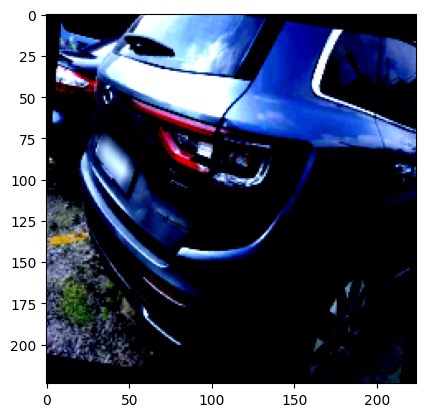

In [13]:
plt.imshow(images[0].permute(1,2,0))
plt.show()

In [14]:
labels[0]

tensor(3)

In [38]:
def train_model(model,criterion,optimizer,epochs=5):
    start_time = time.time()
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch,(images,labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            
            outputs = model(images)
            loss = criterion(outputs,labels)

            loss.backward()
            optimizer.step()

            if(batch+1)%10 == 0:
                print(f"Batch : {batch+1} , Epoch :{epoch+1} , Loss :{loss.item():0.2f}")

            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
# Validation
        model.eval()
        correct = 0
        total = 0
        all_labels = []
        all_predictions = []
        with torch.no_grad():
            for images,labels in val_loader:
                images , labels = images.to(device),labels.to(device)
    
                outputs = model(images)
                _,predicted = torch.max(outputs.data,1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                all_labels.extend(labels.cpu().numpy()) 
                all_predictions.extend(predicted.cpu().numpy())
        
            print(f"Validation Accuracy : {correct*100/total:.2f}%")
    end_time = time.time()
    print(f"Execution Time : {end_time - start_time}")
    return all_labels,all_predictions

## Model 4 : Transfer Learning with ResNet

In [15]:
# Load the pre-trained Reset model
class carClassifierResNet(nn.Module):
    def __init__(self,num_classes,dropout_rate = 0.5):
        super().__init__()
        self.model = models.resnet50(weights = 'DEFAULT')
        #Freeze All Layers
        for param in self.model.parameters():
            param.requires_grad = False
            
        #Unfreeze layer 4 and FC layer
        for param in self.model.layer4.parameters():
            param.requires_grad = True

        #Replace Fully Connected Layer
        self.model.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(self.model.fc.in_features,num_classes)
        )
    def forward(self,x):
        x = self.model(x)
        return x

In [53]:
model = carClassifierResNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p : p.requires_grad , model.parameters()),lr = 0.001)
labels,predictions = train_model(model,criterion,optimizer,epochs = 10)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /Users/abhinavjain/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████████████████████████████████| 97.8M/97.8M [00:22<00:00, 4.49MB/s]


Batch : 10 , Epoch :1 , Loss :1.09
Batch : 20 , Epoch :1 , Loss :0.92
Batch : 30 , Epoch :1 , Loss :0.81
Batch : 40 , Epoch :1 , Loss :0.65
Batch : 50 , Epoch :1 , Loss :0.80
Validation Accuracy : 70.61%
Batch : 10 , Epoch :2 , Loss :0.33
Batch : 20 , Epoch :2 , Loss :0.47
Batch : 30 , Epoch :2 , Loss :0.27
Batch : 40 , Epoch :2 , Loss :0.91
Batch : 50 , Epoch :2 , Loss :0.37
Validation Accuracy : 76.70%
Batch : 10 , Epoch :3 , Loss :0.37
Batch : 20 , Epoch :3 , Loss :0.34
Batch : 30 , Epoch :3 , Loss :0.39
Batch : 40 , Epoch :3 , Loss :0.38
Batch : 50 , Epoch :3 , Loss :0.37
Validation Accuracy : 78.96%
Batch : 10 , Epoch :4 , Loss :0.16
Batch : 20 , Epoch :4 , Loss :0.12
Batch : 30 , Epoch :4 , Loss :0.23
Batch : 40 , Epoch :4 , Loss :0.35
Batch : 50 , Epoch :4 , Loss :0.17
Validation Accuracy : 77.57%
Batch : 10 , Epoch :5 , Loss :0.29
Batch : 20 , Epoch :5 , Loss :0.13
Batch : 30 , Epoch :5 , Loss :0.14
Batch : 40 , Epoch :5 , Loss :0.07
Batch : 50 , Epoch :5 , Loss :0.11
Validatio

In [16]:
def objective(trial):
    lr = trial.suggest_float('lr',1e-5,1e-2,log = True)
    dropout_rate = trial.suggest_float('dropout_rate',0.2,0.7)

    model =carClassifierResNet(num_classes = num_classes,dropout_rate = dropout_rate).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p : p.requires_grad , model.parameters()),lr = lr)

    epochs = 3
    start = time.time()
    for epoch in range(epochs):
        model.train()
        runnig_loss = 0.0
        for batch , (images,labels) in enumerate(train_loader):
            images,labels = images.to(device),labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs,labels)
            loss.backward()
            optimizer.step()
            running_loss = loss.item() * images.size(0)
        epoch_loss = running_loss/len(train_loader.dataset)

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images,labels in val_loader:
                images,labels = images.to(device),labels.to(device)
                outputs = model(images)
                _,predicted = torch.max(outputs.data,1)
                total += labels.size(0)
                correct = (predicted==labels).sum().item()
        accuracy = 100 * correct / total

        trial.report(accuracy,epoch)

        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    end = time.time()
    print(f"Execution Time : {end - start} seconds")
    return accuracy
                
    
    

In [23]:
study = optuna.create_study(direction = 'maximize')
study.optimize(objective,n_trials = 20)

[I 2026-03-23 15:33:33,073] A new study created in memory with name: no-name-e4299d93-9877-4357-84de-e00930595a64
[I 2026-03-23 15:37:10,601] Trial 0 finished with value: 4.695652173913044 and parameters: {'lr': 0.00047421963813536883, 'dropout_rate': 0.40684696408757837}. Best is trial 0 with value: 4.695652173913044.


Execution Time : 216.6499080657959 seconds


[I 2026-03-23 15:40:42,384] Trial 1 finished with value: 4.0 and parameters: {'lr': 0.0072456140362557415, 'dropout_rate': 0.3906144747636115}. Best is trial 0 with value: 4.695652173913044.


Execution Time : 211.24518704414368 seconds


[I 2026-03-23 15:44:31,462] Trial 2 finished with value: 4.695652173913044 and parameters: {'lr': 0.00017694903655696178, 'dropout_rate': 0.4886877546365009}. Best is trial 0 with value: 4.695652173913044.


...

Execution Time : 237.88315796852112 seconds


[I 2026-03-23 15:57:33,324] Trial 6 pruned. 
[I 2026-03-23 16:01:26,777] Trial 7 finished with value: 4.521739130434782 and parameters: {'lr': 0.000508892844086157, 'dropout_rate': 0.3203134685246317}. Best is trial 0 with value: 4.695652173913044.


Execution Time : 231.4810311794281 seconds


[I 2026-03-23 16:02:47,036] Trial 8 pruned. 
[I 2026-03-23 16:04:05,860] Trial 9 pruned. 
[I 2026-03-23 16:05:24,285] Trial 10 pruned. 
[I 2026-03-23 16:06:39,229] Trial 11 pruned. 
[I 2026-03-23 16:07:54,800] Trial 12 pruned. 
[W 2026-03-23 16:08:56,628] Trial 13 failed with parameters: {'lr': 8.498916228326473e-05, 'dropout_rate': 0.47193430284785143} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/optuna/study/_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/20/27w0t1h90vx_vgnlv5xf4w0w0000gn/T/ipykernel_14129/3729752306.py", line 29, in objective
    for images,labels in val_loader:
                         ^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/utils/data/dataloader.py", line 741, in __next__
    data = self._next_data()
  File "/Library/Framework

KeyboardInterrupt: 

In [24]:
study.best_params

{'lr': 0.00047421963813536883, 'dropout_rate': 0.40684696408757837}